# Assignment: Exploratory Data Analysis
### `! git clone https://github.com/ds4e/visualization`
### Do One.

**Q1.** This question provides some practice doing exploratory data analysis and visualization.

The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `./data/college_completion.csv` data with Pandas.
2. What are are the dimensions of the data? How many observations are there? What are the variables included? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see.
4. For `grad_100_value`, create a histogram, kernel density plot, boxplot, and statistical description.
5. For `grad_100_value`, create a grouped kernel density plot by `control` and by `level`. Describe what you see. Use `groupby` and `.describe` to make grouped calculations of statistical descriptions of `grad_100_value` by `level` and `control`. Which institutions appear to have the best graduation rates?
6. Create a new variable, `df['levelXcontrol']=df['level']+', '+df['control']` that interacts level and control. Make a grouped kernel density plot. Which institutions appear to have the best graduation rates?
7. Make a kernel density plot of `aid_value`. Now group your graph by `level` and `control`. What explains the shape of the graph? Use `groupby` and `.describe` to make grouped calculations of statistical descriptions of `aid_value` by `level` and `control`.
8. Make a scatterplot of `grad_100_value` by `aid_value`. Describe what you see. Now make the same plot, grouping by `level` and then `control`. Describe what you see. For which kinds of institutions does aid seem to increase graduation rates?

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [6]:
import requests
file = "https://raw.githubusercontent.com/ds4e/visualization/refs/heads/main/assignment/data/college_completion.csv"
df = pd.read_csv(file)


In [8]:
print("The dimensions are:")
print(df.shape)
print("There are this many observations")
print(df.shape[0])
print("These are the variables")
print(df.columns)
df.head()

The dimensions are:
(3798, 63)
There are this many observations
3798
These are the variables
Index(['index', 'unitid', 'chronname', 'city', 'state', 'level', 'control',
       'basic', 'hbcu', 'flagship', 'long_x', 'lat_y', 'site', 'student_count',
       'awards_per_value', 'awards_per_state_value', 'awards_per_natl_value',
       'exp_award_value', 'exp_award_state_value', 'exp_award_natl_value',
       'exp_award_percentile', 'ft_pct', 'fte_value', 'fte_percentile',
       'med_sat_value', 'med_sat_percentile', 'aid_value', 'aid_percentile',
       'endow_value', 'endow_percentile', 'grad_100_value',
       'grad_100_percentile', 'grad_150_value', 'grad_150_percentile',
       'pell_value', 'pell_percentile', 'retain_value', 'retain_percentile',
       'ft_fac_value', 'ft_fac_percentile', 'vsa_year',
       'vsa_grad_after4_first', 'vsa_grad_elsewhere_after4_first',
       'vsa_enroll_after4_first', 'vsa_enroll_elsewhere_after4_first',
       'vsa_grad_after6_first', 'vsa_grad_elsew

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


In [10]:
pd.crosstab(df['control'], df['level'], normalize=True)

level,2-year,4-year
control,,
Private for-profit,0.122433,0.138757
Private not-for-profit,0.017904,0.310690
Public,0.243813,0.166403


Some of the patterns from the table above are
- Public schools are usually 2 year institutions
- Private schools are usually 4 year institutions
- A private not for profit is much more likely to be a 4 year instituion, rather than a 2 year institution


In [11]:
df['grad_100_value'].describe()

,grad_100_value
count,3467.000000
mean,28.364465
std,23.312730
min,0.000000
25%,9.000000
50%,22.500000
75%,43.650000
max,100.000000


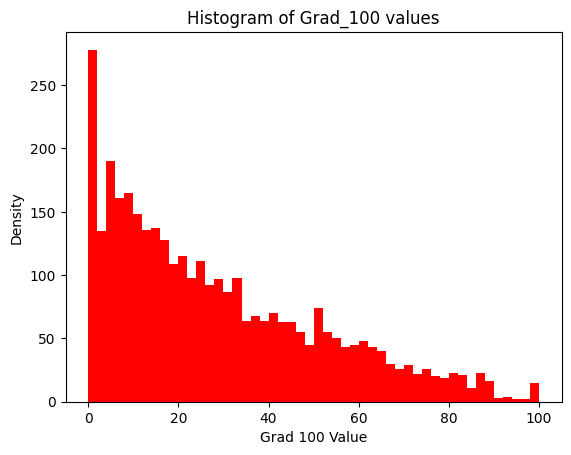

In [16]:
plt.hist(x = df['grad_100_value'], bins =50, color = "red")
plt.title("Histogram of Grad_100 values")
plt.xlabel("Grad 100 Value")
plt.ylabel("Density")
plt.show()

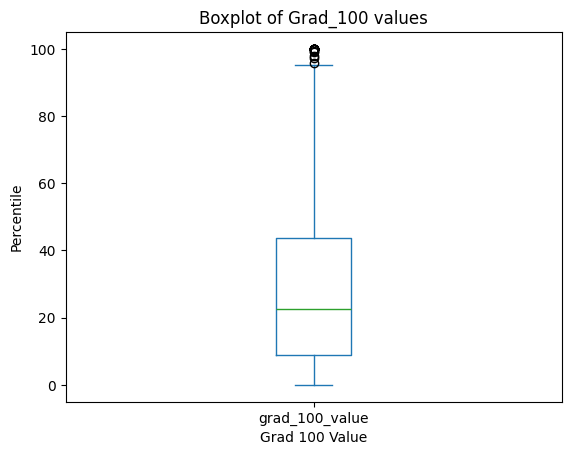

In [24]:
data = df['grad_100_value']
data.plot.box()
plt.title("Boxplot of Grad_100 values")
plt.xlabel("Grad 100 Value")
plt.ylabel("Percentile")
plt.show()

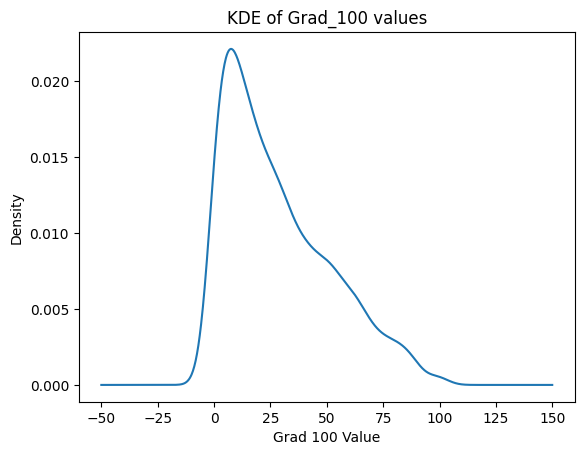

In [25]:
data.plot.density()
plt.title("KDE of Grad_100 values")
plt.xlabel("Grad 100 Value")
plt.ylabel("Density")
plt.show()

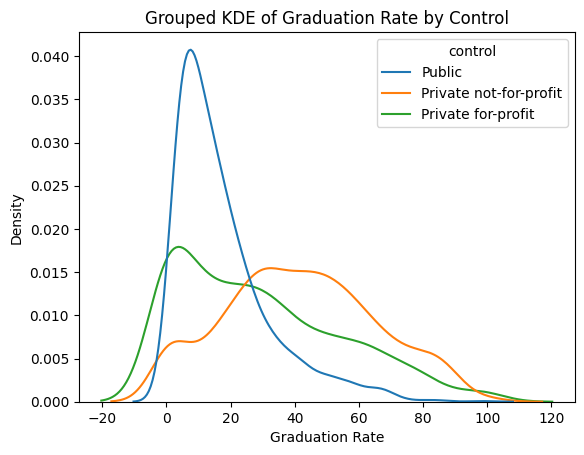

In [51]:
sns.kdeplot( data=df, x="grad_100_value", hue='control', common_norm=False)
plt.title('Grouped KDE of Graduation Rate by Control')
plt.xlabel('Graduation Rate')
plt.ylabel('Density')
plt.show()

Publc instiutions have the greatest density of grad 100 values around 20, while private for non profits have a lower and longer density, with a higher density of higher grad 100 values.

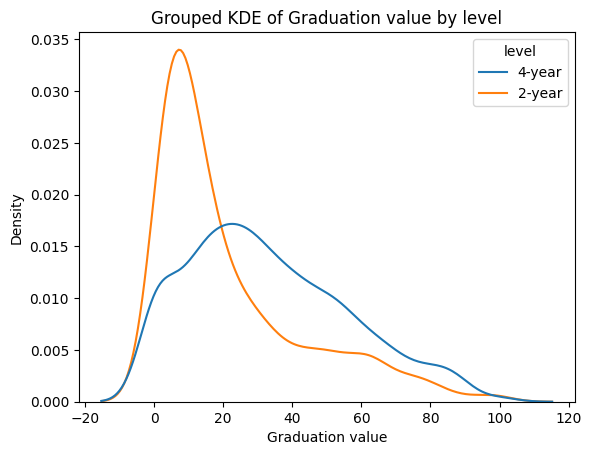

In [50]:
sns.kdeplot( data=df, x="grad_100_value", hue='level', common_norm=False)
plt.title('Grouped KDE of Graduation value by level')
plt.xlabel('Graduation value')
plt.ylabel('Density')
plt.show()

2-year instituions have a high amount of grad 100 values at at a low value, about 15. 4-year institutions have a more level amount and a higher density of more medium values.

In [28]:
df['grad_100_value'].groupby(df['level']).describe()

,count,mean,std,min,25%,50%,75%,max
level,,,,,,,,
2-year,1455.0,21.636151,21.645747,0.0,6.0,13.0,30.600,100.0
4-year,2012.0,33.230119,23.270160,0.0,15.2,29.7,49.225,100.0


In [29]:
df['grad_100_value'].groupby(df['control']).describe()

,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


The institutions that appear to have the best average graduation rate are private not-for-profit ones and 4-year institutions.

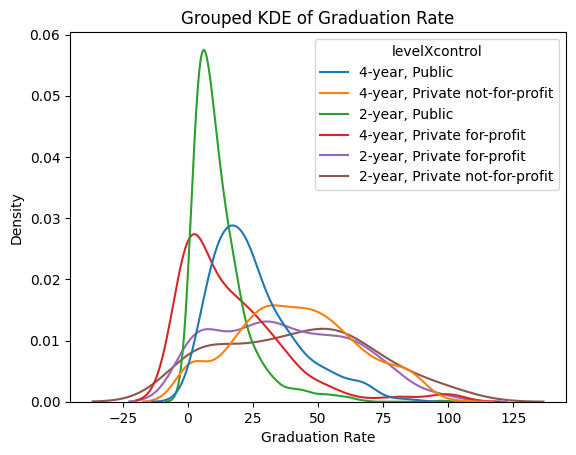

In [47]:
df['levelXcontrol']=df['level']+', '+df['control']
sns.kdeplot(data=df, x="grad_100_value", hue='levelXcontrol', common_norm=False)
plt.title('Grouped KDE of Graduation Rate')
plt.xlabel('Graduation Rate')
plt.ylabel('Density')
plt.show()

The institution that appears to have the best graduation rate is 2-year private not-for profit universities. They have a relatively flat, but moderately high density of graduation rates near 60%. 2-year public institutions appear to have the worst graduation rate.

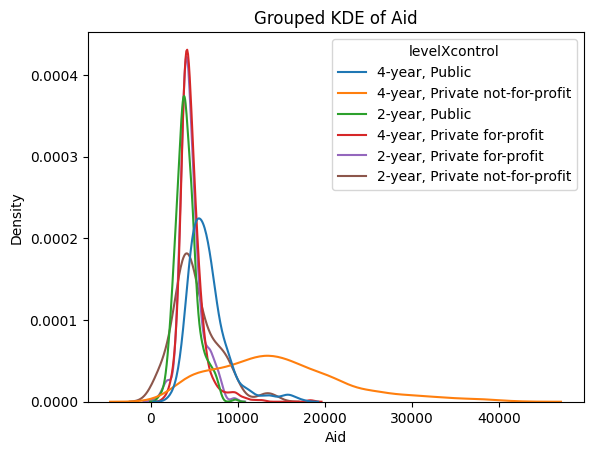

In [46]:
sns.kdeplot(data=df, x="aid_value", hue='levelXcontrol', common_norm=False)
plt.title('Grouped KDE of Aid')
plt.xlabel('Aid')
plt.ylabel('Density')
plt.show()

The shape of the graph can be explained by the fact that private instituions usually have more money to give out to students for financial aid. Also non-profit universities are using their money for students, not for generating profit. It is also 4-year private non-for-profit universities that give out the most aid as students have to spend more time at the univeristy, have to pay more tuition, and ultimately need more aid.

In [37]:
df['aid_value'].groupby(df['levelXcontrol']).describe()

,count,mean,std,min,25%,50%,75%,max
levelXcontrol,,,,,,,,
"2-year, Private for-profit",464.0,4559.681034,1286.688269,294.0,3818.75,4286.5,5122.00,9727.0
"2-year, Private not-for-profit",68.0,5128.058824,2590.449946,934.0,3650.00,4516.5,6311.50,13654.0
"2-year, Public",926.0,4126.199784,1260.271382,881.0,3311.25,3943.5,4762.00,9809.0
"4-year, Private for-profit",527.0,4696.062619,1489.410020,1580.0,3885.50,4364.0,5131.50,18355.0
"4-year, Private not-for-profit",1180.0,14702.401695,7649.775203,902.0,9113.25,13774.5,18996.75,41580.0
"4-year, Public",632.0,6514.071203,2353.716693,2232.0,4990.50,6085.0,7341.50,17299.0


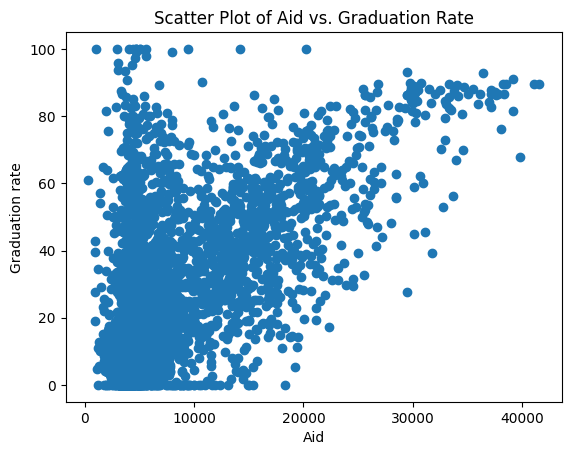

In [45]:
plt.scatter(data = df, x = 'aid_value', y = "grad_100_value")
plt.title('Scatter Plot of Aid vs. Graduation Rate')
plt.xlabel('Aid')
plt.ylabel('Graduation rate')
plt.show()

The scatter plot above shows that universities with a lower graduation rate also give less aid to students, generally. There is also a correlation between the amount of aid given and the graduation rate.

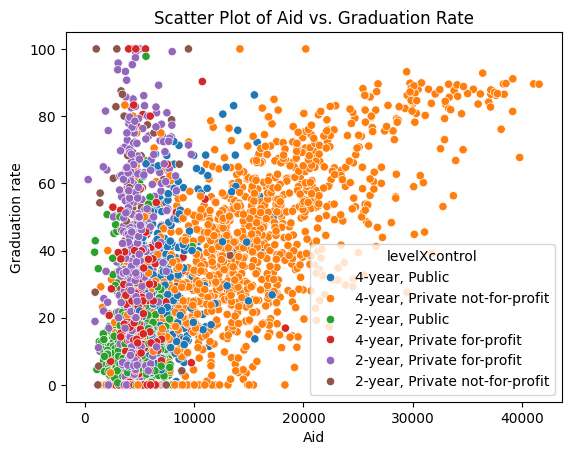

In [44]:
sns.scatterplot(data = df, x = 'aid_value', y = "grad_100_value", hue = "levelXcontrol")
plt.title('Scatter Plot of Aid vs. Graduation Rate')
plt.xlabel('Aid')
plt.ylabel('Graduation rate')
plt.show()

From this graph we can see that 4-year private not-for-profit universities have a strong correlation between graduation rates and aid given. On the other hand, 2-year private not for profit seems to have no correlation between aid given and graduation rates, the same with public 4-year institutions. Specifically, the amount of aid given seems to increase the graduation rate of 4-year private not-for-profit universities the most.

**Q2.** Go to https://data.cms.gov/search.
1. Pick a dataset about something you are interested in. Download the data and data dictionary. If you really can't decide, you can always use this one: https://data.cms.gov/medicare-current-beneficiary-survey-mcbs/medicare-current-beneficiary-survey-data
3. Does the data dictionary document how missings are handled? For categorical variables, does it describe the possible values and missing value codes? For the numeric variables, does it describe how missing values are handled? Summarize your opinion of the data dictionary.
4. Pick out a few interesting variables, and explain why you find them jointly interesting. Clean those variables, documenting your choices by commenting in the code or in a markdown chunk in a notebook.
5. For the variables you select, make a boxplot for each numeric variable and a bar graph for each categorical variable. Do you see any outliers?
6. Create a histogram or kernel density plot, and explain what you see. Do the results require any transformations to rescale them?
7. Create a scatter plot, and describe the relationship you see.
8. Create a table (cross tabulation, variance-covariance, or a `.describe()` five-number summary), and explain what you see.

**Q3.** This is a case study about understanding and visualizing risk over time, involving a dataset with information about breast cancer mortality rates over time, conditional on different treatments.

1. Load the `./data/Breast Cancer METABRIC.csv` dataset. It has a bunch of interesting variables, but the mains of interest for this question are `Overall Survival (Months)`, which is  and `Overall Survival Survival Status`, which records whether the patient is Alive or Deceased.
2. Make one kernel density plot of `Overall Survival (Months)`, and a second conditional on `Overall Survival Status`. Interpret these plots. What patterns do you see?

3. The **hazard rate** gives the instantaneous risk of an event occurring, given that it hasn't already happened. It is defined as
$$
h(t) = \dfrac{f(t)}{1-F(t)}
$$
where $F(t)$ is the distribution of arrival times and $f(t)=F'(t)$ is the density of arrival times. Roughly, conditional on $T \ge t$, what is the probability that $T=t$? The cumulative hazard is given by
$$
H(t) = \int_0^t h(z) dz.
$$
The following function computes the hazard rate and cumulative hazard using something called the Nelson-Ahlen estimator. Run your data through it. Interpret the plots for the hazard rate and cumulative hazard rate. What patterns do you see?

```
def hazard(df):
    """ Compute cumulative hazard rate using Nelson-Ahlen estimator. """
    at_risk = df.shape[0]
    arrivals = df['survival'].sort_values().dropna().tolist()
    hazard_rate = []
    times = []
    for t in arrivals:
        select = (df['survival']==t)*(df['Overall Survival Status']=='Deceased')
        deaths_t = df[select].shape[0]
        if deaths_t > 0:
            hazard_rate.append(deaths_t/at_risk)
            times.append(t)
            at_risk -= deaths_t
    cumulative_hazard = np.cumsum(hazard_rate)
    return cumulative_hazard, times, hazard_rate
```

4. There are lots of additional categorical variables in the METABRIC dataset. Pick a categorical variable, and plot the hazard rate and cumulative hazard for each category. Do you see any interesting patterns? Is one group more likely to survive, or do their hazard rates cross over time?
5. These plots are very helpful for understanding how patients respond to treatment. Discuss how they might be used in practice, to help doctors and patients make decisions about care.

**Q4.** Write your own function to make a kernel density plot.

- The user should pass in a Pandas series or Numpy array.
- The default kernel should be Gaussian, but include the uniform/bump and Epanechnikov as alternatives.
- The default bandwidth should be the Silverman plug-in, but allow the user to specify an alternative.
- You can use Matplotlib or Seaborn's `.lineplot`, but not an existing function that creates kernel density plots.

You will have to make a lot of choices and experiment with getting errors. Embrace the challenge and track your choices in the comments in your code.

Use a data set from class to show that your function works, and compare it with the Seaborn `kdeplot`.

We covered the Gaussian,
$$
k(z) = \dfrac{1}{\sqrt{2\pi}}e^{-z^2/2}
$$
and uniform
$$
k(z) = \begin{cases}
\frac{1}{2}, & |z| \le 1 \\
0, & |z|>1
\end{cases}
$$
kernels in class, but the Epanechnikov kernel is
$$
k(z) = \begin{cases}
\frac{3}{4} (1-z^2), & |z| \le 1 \\
0, & |z|>1.
\end{cases}
$$

In order to make your code run reasonably quickly, consider using the `pdist` or `cdist` functions from SciPy to make distance calculations for arrays of points. The other leading alternative is to thoughtfully use NumPy's broadcasting features. Writing `for` loops will be slow, but that's fine.